# Step 0 — Load data & features

In [7]:
import pandas as pd
import numpy as np
from scipy.sparse import load_npz
import joblib

# Load dataset
df = pd.read_csv("books_with_clusters.csv")

# Check columns
print(df.columns)

# Load TF-IDF matrix from Part A
X = load_npz("tfidf_matrix.npz")

# Use keyword_category as label
y = df["keyword_category"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts().head())

Index(['Title', 'Authors', 'year', 'Description', 'description_clean',
       'text_clean', 'keyword_category', 'cluster'],
      dtype='object')
X shape: (1985, 5000)
y shape: (1985,)
keyword_category
other       539
fiction     401
history     287
military    243
travel      206
Name: count, dtype: int64


# Step 1 — Train/Test Split (80/20)

In [8]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1588, 5000)
X_test: (397, 5000)
y_train: (1588,)
y_test: (397,)


# Step 2 — Train Three Classification Models

**2.1 Naive Bayes**

In [9]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Prediction
nb_pred = nb_model.predict(X_test)

print("Naive Bayes training completed.")

Naive Bayes training completed.


**2.2 Logistic Regression**

In [10]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

print("Logistic Regression training completed.")

Logistic Regression training completed.


**2.3 Random Forest**

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


# Step 3 — Model Evaluation (Precision / Recall / F1-score)

In [12]:
from sklearn.metrics import classification_report, accuracy_score

print("===== Naive Bayes =====")
print(classification_report(y_test, nb_pred))
print("Accuracy:", accuracy_score(y_test, nb_pred))

print("\n===== Logistic Regression =====")
print(classification_report(y_test, lr_pred))
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\n===== Random Forest =====")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))

===== Naive Bayes =====
              precision    recall  f1-score   support

   biography       0.00      0.00      0.00         2
    business       0.00      0.00      0.00         8
     fiction       0.43      0.55      0.48        80
     history       0.75      0.10      0.18        58
     medical       0.00      0.00      0.00        10
    military       0.00      0.00      0.00        49
       other       0.36      0.95      0.52       108
  psychology       0.00      0.00      0.00         7
    romantic       0.00      0.00      0.00        27
  scientific       0.00      0.00      0.00         7
      travel       0.00      0.00      0.00        41

    accuracy                           0.39       397
   macro avg       0.14      0.15      0.11       397
weighted avg       0.29      0.39      0.27       397

Accuracy: 0.3853904282115869

===== Logistic Regression =====
              precision    recall  f1-score   support

   biography       0.00      0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

**Summary Table**

In [13]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

results = []

for name, pred in {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred
}.items():

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.385390,0.294815,0.385390,0.266593
1,Logistic Regression,0.483627,0.457512,0.483627,0.391310
2,Random Forest,0.727960,0.731871,0.727960,0.697825


# Step 4 — Confusion Matrix

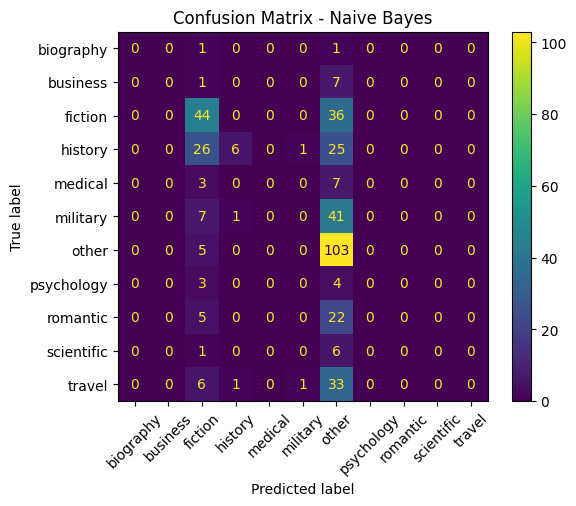

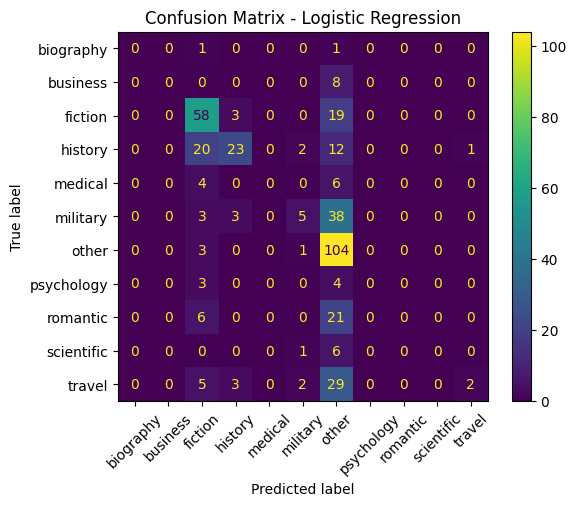

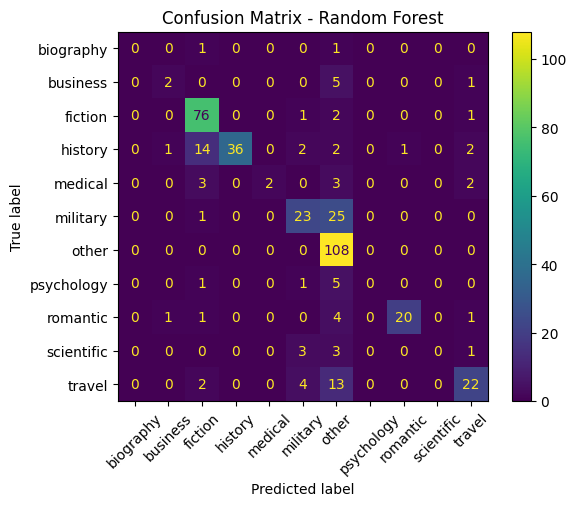

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(y.unique())

# Naive Bayes
cm_nb = confusion_matrix(y_test, nb_pred, labels=labels)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=labels)
disp_nb.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred, labels=labels)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels)
disp_lr.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred, labels=labels)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)
disp_rf.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Step 5 — Error Analysis

**5.1 Attach predictions to test dataset**

In [15]:
df_test = df_test.copy()

df_test["true_label"] = y_test.values
df_test["NB_pred"] = nb_pred
df_test["LR_pred"] = lr_pred
df_test["RF_pred"] = rf_pred

**5.2 Logistic Regression errors**

In [16]:
lr_errors = df_test[df_test["true_label"] != df_test["LR_pred"]]

print("Number of LR misclassified samples:", len(lr_errors))

lr_errors[["Title", "true_label", "LR_pred", "Description"]].head(10)

Number of LR misclassified samples: 205


,Title,true_label,LR_pred,Description
1749,"3rd Degree (Women's Murder Club, #3)",medical,other,The Women's Murder Club returns in a shockingl...
1543,Let It Snow: Three Holiday Romances,romantic,other,Alternate cover edition for B006MOW98ESparklin...
1875,"Love Unscripted (Love, #1)",romantic,other,An A-List Movie Star. . . Ryan Christensen jus...
1839,"Queen of Babble (Queen of Babble, #1)",travel,other,"What's an American girl with a big mouth, but ..."
548,The Omnivore's Dilemma: A Natural History of F...,fiction,other,What should we have for dinner? For omnivore's...
509,"Postmortem (Kay Scarpetta, #1)",medical,other,"Four women with nothing in common, united only..."
616,The Hound of the Baskervilles,history,fiction,We owe The Hound of the Baskervilles (1902) to...
667,The House of the Spirits,fiction,other,La casa de los espíritus narra la saga de una ...
260,Under the Tuscan Sun,travel,other,"An enchanting and lyrical look at the life, th..."
1982,"Come Away with Me (With Me in Seattle, #1)",romantic,other,An alternate cover edition can be found here.B...


**5.3 Compare model errors**

In [17]:
nb_error_count = (df_test["true_label"] != df_test["NB_pred"]).sum()
lr_error_count = (df_test["true_label"] != df_test["LR_pred"]).sum()
rf_error_count = (df_test["true_label"] != df_test["RF_pred"]).sum()

import pandas as pd

error_compare = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Random Forest"],
    "Number of Errors": [nb_error_count, lr_error_count, rf_error_count]
})

error_compare = error_compare.sort_values(by="Number of Errors")
error_compare

,Model,Number of Errors
2,Random Forest,108
1,Logistic Regression,205
0,Naive Bayes,244


**5.4 Visualization of errors**

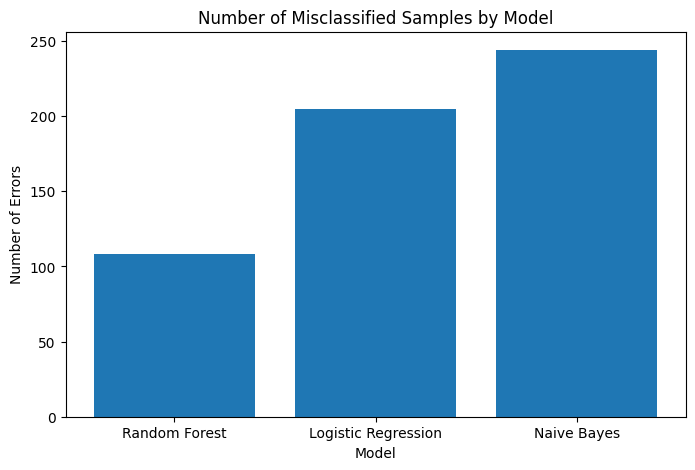

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(error_compare["Model"], error_compare["Number of Errors"])
plt.title("Number of Misclassified Samples by Model")
plt.xlabel("Model")
plt.ylabel("Number of Errors")
plt.show()

**5.5 Most confused categories**

In [19]:
lr_confusions = (
    lr_errors.groupby(["true_label", "LR_pred"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

lr_confusions.head(10)

,true_label,LR_pred,count
13,military,other,38
25,travel,other,29
19,romantic,other,21
5,history,fiction,20
4,fiction,other,19
7,history,other,12
2,business,other,8
10,medical,other,6
21,scientific,other,6
18,romantic,fiction,6


# Recommender System (Surprise + RMSE)

# Step 1 — Load book rating summary data

In [20]:
import pandas as pd
import numpy as np

books_full = pd.read_csv("Books.csv")

print(books_full.columns)
print(books_full[["book_id", "title", "average_rating", "ratings_count"]].head())

Index(['Unnamed: 0', 'id', 'book_id', 'best_book_id', 'work_id', 'books_count',
       'isbn', 'isbn13', 'authors', 'original_publication_year',
       'original_title', 'title', 'language_code', 'average_rating',
       'ratings_count', 'work_ratings_count', 'work_text_reviews_count',
       'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5',
       'image_url', 'small_image_url', 'goodreads_book_id', 'tag_name',
       'description'],
      dtype='object')
   book_id                                              title  average_rating  \
0  2767052            The Hunger Games (The Hunger Games, #1)            4.34   
1        3  Harry Potter and the Sorcerer's Stone (Harry P...            4.44   
2    41865                            Twilight (Twilight, #1)            3.57   
3     2657                              To Kill a Mockingbird            4.25   
4     4671                                   The Great Gatsby            3.89   

   ratings_count  
0        4780653  

# Step 2 — Keep useful columns only

In [21]:
rating_cols = ["book_id", "title", "average_rating", "ratings_count",
               "ratings_1", "ratings_2", "ratings_3", "ratings_4", "ratings_5"]

books_ratings = books_full[rating_cols].copy()

# Remove books with missing values
books_ratings = books_ratings.dropna(subset=["book_id", "average_rating"])

# To keep runtime manageable, sample a smaller set of books
books_ratings = books_ratings.sample(n=min(500, len(books_ratings)), random_state=42)

print("Number of sampled books:", len(books_ratings))
books_ratings.head()

Number of sampled books: 500


,book_id,title,average_rating,ratings_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
1860,476543,The Darkest Night (Lords of the Underworld #1),4.09,63240,1611,3257,11686,20304,29088
353,6149,Beloved,3.77,233825,12441,21409,53863,79915,77470
1333,47989,"Night Watch (Discworld, #29; City Watch, #6)",4.47,71271,232,724,7113,24480,46568
905,6643090,Major Pettigrew's Last Stand,3.87,97745,1652,5870,26114,46749,28926
1289,10798416,The Statistical Probability of Love at First S...,3.80,89356,2569,7379,25452,32106,28350


# Step 3 — Create pseudo user-book ratings

This code uses each book’s rating distribution to simulate user feedback.

In [22]:
pseudo_ratings = []

np.random.seed(42)
n_users = 300   # you can change this if needed

for _, row in books_ratings.iterrows():
    book_id = row["book_id"]

    # rating distribution from Goodreads summary counts
    dist = {
        1: int(row.get("ratings_1", 0)),
        2: int(row.get("ratings_2", 0)),
        3: int(row.get("ratings_3", 0)),
        4: int(row.get("ratings_4", 0)),
        5: int(row.get("ratings_5", 0))
    }

    total = sum(dist.values())
    if total == 0:
        continue

    # normalize probabilities
    probs = np.array([dist[1], dist[2], dist[3], dist[4], dist[5]], dtype=float)
    probs = probs / probs.sum()

    # simulate a limited number of users rating this book
    sampled_users = np.random.choice(range(1, n_users + 1), size=min(20, n_users), replace=False)
    sampled_ratings = np.random.choice([1, 2, 3, 4, 5], size=len(sampled_users), p=probs)

    for u, r in zip(sampled_users, sampled_ratings):
        pseudo_ratings.append([u, book_id, r])

ratings_df = pd.DataFrame(pseudo_ratings, columns=["user_id", "book_id", "rating"])

print(ratings_df.head())
print("Shape:", ratings_df.shape)

   user_id  book_id  rating
0      204   476543       5
1      267   476543       5
2      153   476543       4
3       10   476543       5
4      234   476543       4
Shape: (10000, 3)


# Step 4 — Train SVD recommender with Surprise

In [23]:
!pip install "numpy<2"

In [24]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Define rating scale
reader = Reader(rating_scale=(1, 5))

# Load into Surprise
data = Dataset.load_from_df(ratings_df[["user_id", "book_id", "rating"]], reader)

# Split into train and test sets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train SVD
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

# Predict
predictions = svd_model.test(testset)

# Evaluate
rmse = accuracy.rmse(predictions)

print("RMSE:", rmse)

RMSE: 1.0000
RMSE: 1.0000050483044935


# Step 5 — Predict a rating for one user-book pair

In [25]:
# Example prediction
sample_user = ratings_df["user_id"].iloc[0]
sample_book = ratings_df["book_id"].iloc[0]

pred = svd_model.predict(sample_user, sample_book)
print("Predicted rating:", pred.est)

Predicted rating: 3.85187238221813


# Step 6 — Recommend top books for one user

In [26]:
# Get all unique books
all_books = ratings_df["book_id"].unique()

# Books already rated by this user
rated_books = ratings_df[ratings_df["user_id"] == sample_user]["book_id"].tolist()

# Predict unseen books
unseen_books = [b for b in all_books if b not in rated_books]

recommendations = []
for book in unseen_books[:200]:   # limit for speed
    pred = svd_model.predict(sample_user, book)
    recommendations.append((book, pred.est))

# Sort by estimated rating
recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)[:10]

# Convert to dataframe
rec_df = pd.DataFrame(recommendations, columns=["book_id", "predicted_rating"])
rec_df = rec_df.merge(books_full[["book_id", "title"]], on="book_id", how="left")

rec_df

,book_id,predicted_rating,title
0,1215032,4.526006,"The Wise Man's Fear (The Kingkiller Chronicle,..."
1,28260587,4.318874,"Empire of Storms (Throne of Glass, #5)"
2,13104080,4.288358,"Unravel Me (Shatter Me, #2)"
3,10572,4.276477,"A Clash of Kings (A Song of Ice and Fire, #2)"
4,301736,4.271695,Guess How Much I Love You
5,567795,4.255370,The Five Love Languages: How to Express Heartf...
6,25111004,4.233613,November 9
7,12216302,4.212023,"Cold Days (The Dresden Files, #14)"
8,30120,4.208949,Falling Up
9,6854,4.205763,"Three to Get Deadly (Stephanie Plum, #3)"
